In [506]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gensim
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
import tensorflow as tf
import keras

In [507]:
train = pd.read_csv("train.csv")
train.head(10)

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative
5,28b57f3990,http://www.dothebouncy.com/smf - some shameles...,http://www.dothebouncy.com/smf - some shameles...,neutral
6,6e0c6d75b1,2am feedings for the baby are fun when he is a...,fun,positive
7,50e14c0bb8,Soooo high,Soooo high,neutral
8,e050245fbd,Both of you,Both of you,neutral
9,fc2cbefa9d,Journey!? Wow... u just became cooler. hehe....,Wow... u just became cooler.,positive


In [508]:
train.groupby("sentiment").nunique()

,textID,text,selected_text
sentiment,,,
negative,7781,7781,5861
neutral,11118,11117,11111
positive,8582,8582,5537


In [509]:
train = train[["selected_text","sentiment"]]
train.head(10)

,selected_text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD,negative
2,bullying me,negative
3,leave me alone,negative
4,"Sons of ****,",negative
5,http://www.dothebouncy.com/smf - some shameles...,neutral
6,fun,positive
7,Soooo high,neutral
8,Both of you,neutral
9,Wow... u just became cooler.,positive


In [510]:
train["selected_text"] = train["selected_text"].fillna("No content")

In [511]:
# Data cleaning
def depure_data(data):
    # Remove URLs with a regular expression
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    data = url_pattern.sub(r'', data)
    # Remove emails
    data = re.sub('\S*@\S*\s?', '', data)
    # Remove new line characters
    data = re.sub('\s+', ' ', data)
    # Remove distracting single quotes
    data = re.sub("\'", "", data)
    return data

# Remove repeating words from dataset
def sentences_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence),     deacc=True))

# Normalize text, lowercase
def clean_text(text):
    text = depure_data(str(text))
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

train["best_text"] = train["selected_text"].fillna("No content").apply(clean_text)
train["best_text"].head(10)

0                  i`d have responded, if i were going
1                                             sooo sad
2                                          bullying me
3                                       leave me alone
4                                        sons of ****,
5    - some shameless plugging for the best rangers...
6                                                  fun
7                                           soooo high
8                                          both of you
9                         wow... u just became cooler.
Name: best_text, dtype: str

In [512]:
# Label encoding - convert sentiment labels to integers for model to use
y = train["sentiment"].map({"neutral": 0, "negative": 1, "positive": 2}).to_numpy()
labels = tf.keras.utils.to_categorical(y, 3)

In [513]:
# Transform text data into padded sequences for model
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 80

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(train["best_text"])
sequences = tokenizer.texts_to_sequences(train["best_text"])
texts = pad_sequences(sequences, maxlen=max_len)

In [514]:
best_texts = train["best_text"].values
# Split data into train and test data for model
X_train, X_test, y_train, y_test, X_train_texts, X_test_texts = train_test_split(texts, labels, best_texts, test_size=0.2, random_state=42, stratify=y)

# Build Bidirectional GRU Neural Network
model = keras.Sequential()
model.add(layers.Embedding(max_words, 128, input_length=max_len))
model.add(layers.Bidirectional(layers.GRU(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)))
model.add(layers.GlobalMaxPool1D())
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dropout(0.4))
model.add(layers.Dense(3, activation="softmax"))
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)

In [515]:
model.fit(X_train, y_train, validation_split=0.1, epochs=12, batch_size=128, callbacks=[early_stop], verbose=1)

# Print sample predictions for first 10 test examples
print()
print("Sample predictions:")
label_map = {0: "neutral", 1: "negative", 2: "positive"}
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions[:10], axis=1)
true_classes = np.argmax(y_test[:10], axis=1)
for i, (predicted, true, confidence, text) in enumerate(zip(predicted_classes, true_classes, predictions[:10], X_test_texts[:10]), start=1):
    print(f'\nSample {i}: "{text}"')
    print(f"True: {label_map[true]}, Predicted: {label_map[predicted]}, Confidence: {confidence[predicted]:.4f}")

print()
print("Test data:")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print("Model accuracy: ", test_acc)

Epoch 1/12
155/155 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.7048 - loss: 0.7145 - val_accuracy: 0.8040 - val_loss: 0.4832
Epoch 2/12
155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.8594 - loss: 0.3983 - val_accuracy: 0.8267 - val_loss: 0.4578
Epoch 3/12
155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8973 - loss: 0.3081 - val_accuracy: 0.8213 - val_loss: 0.4752
Epoch 4/12
155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9156 - loss: 0.2537 - val_accuracy: 0.8231 - val_loss: 0.5069

Sample predictions:
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

Sample 1: "heart breaking"
True: negative, Predicted: negative, Confidence: 0.6269

Sample 2: "ughhhhhhhh i don`t feel good"
True: negative, Predicted: negative, Confidence: 0.6302

Sample 3: "have spent half of the day troubleshooting something that wasn`t even within my control. clusters doesn`t always mean high availability."
True: neutral, Predicted: neutral, Confidence: 0.6671

Sample 4: "hopefully"
True: positiv

<Axes: >

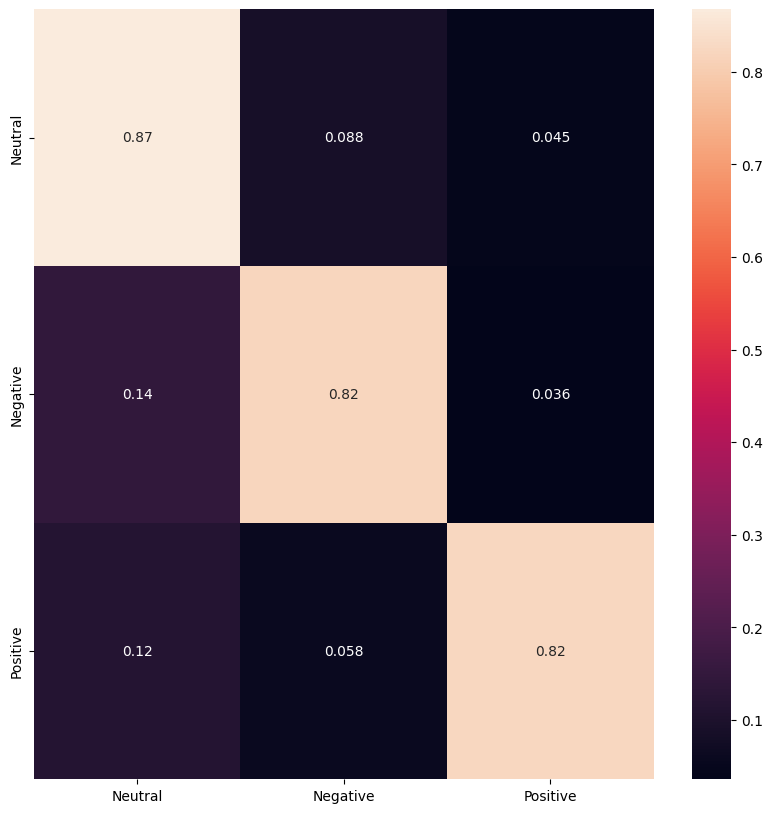

In [516]:
# Plot confusion matrix for model
matrix = confusion_matrix(y_test.argmax(axis=1), np.argmax(predictions, axis=1))
conf_matrix = pd.DataFrame(matrix, index=["Neutral", "Negative", "Positive"], columns=["Neutral", "Negative", "Positive"])
# Normalizing
conf_matrix = conf_matrix.astype("float") / conf_matrix.sum(axis=1).to_numpy()[:, np.newaxis]
plt.figure(figsize=(10,10))
sns.heatmap(conf_matrix, annot=True, annot_kws={"size": 10})